In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ====================================
# Utility
# ====================================

def exp_so3(w, dt):
    """Exponential map for SO(3), integrates angular velocity."""
    th = np.linalg.norm(w * dt)
    if th < 1e-8:
        return np.eye(3)
    k = (w * dt) / th
    K = np.array([[0, -k[2], k[1]],
                  [k[2], 0, -k[0]],
                  [-k[1], k[0], 0]])
    return np.eye(3) + np.sin(th)*K + (1-np.cos(th))*(K @ K)


# ====================================
# Drone Simulator
# ====================================

class DroneSim:
    """
    12-dim quadrotor simulator.
    Input = desired velocity (world frame).
    State = [pos(3), vel(3), R(3x3), omega(3)].
    """

    def __init__(self, mass, J, dt,
                 init_pos_range, init_vel_range, init_omega_range,
                 tau_v,
                 pos_bounds, vel_bounds, omega_bounds,
                 rng):
        # Params
        self.m = mass
        self.J = J
        self.invJ = np.linalg.inv(J)
        self.dt = dt
        self.tau_v = tau_v  # velocity tracking time constant

        # Random initial state
        self.p = rng.uniform(low=init_pos_range[0], high=init_pos_range[1], size=3)
        self.v = rng.uniform(low=init_vel_range[0], high=init_vel_range[1], size=3)
        self.R = np.eye(3)  # start level
        self.omega = rng.uniform(low=init_omega_range[0], high=init_omega_range[1], size=3)

        # Boundaries
        self.pos_bounds = np.array(pos_bounds)
        self.vel_bounds = np.array(vel_bounds)
        self.omega_bounds = np.array(omega_bounds)

    def step(self, v_des):
        """
        One integration step.
        Velocity tracks v_des with first-order lag.
        Orientation propagates with omega.
        """
        # --- velocity tracking
        self.v += (v_des - self.v) * (self.dt /(self.tau_v))

        # --- position update
        self.p += self.v * self.dt

        # --- orientation update
        self.R = self.R @ exp_so3(self.omega, self.dt)

        # --- angular velocity (free drift, no control here)
        self.omega += np.zeros(3)

        # --- enforce boundaries
        self.p = np.clip(self.p, -self.pos_bounds, self.pos_bounds)
        self.v = np.clip(self.v, -self.vel_bounds, self.vel_bounds)
        self.omega = np.clip(self.omega, -self.omega_bounds, self.omega_bounds)

        return self.p.copy(), self.v.copy(), self.R.copy(), self.omega.copy()


# ====================================
# Infinity Pattern (Lemniscate)
# ====================================

def lemniscate_velocity(x, a, k_p, k_t, v_max):
    """
    Infinity-shape vector field: returns desired velocity in XY-plane.
    """
    X, Y = x[0], x[1]

    # implicit function
    f = (X**2 + Y**2)**2 - 2*(a**2)*(X**2 - Y**2)
    gradf = np.array([4*X*(X**2+Y**2) - 4*a**2*X,
                      4*Y*(X**2+Y**2) + 4*a**2*Y])
    gradV = f * gradf

    # tangential term
    T = np.array([-gradf[1], gradf[0]])
    T /= np.linalg.norm(T) + 1e-8

    v_des = -k_p * gradV + k_t * T
    v_norm = np.linalg.norm(v_des)
    if v_norm > v_max:
        v_des = v_des / v_norm * v_max

    return np.array([v_des[0], v_des[1], 0.0])


# ====================================
# Simulation Runner
# ====================================

def run_simulation(steps, dt, sim_params, pattern_params):
    sim = DroneSim(**sim_params)
    traj, v_log, v_des_log = [], [], []

    for _ in range(steps):
        v_des = lemniscate_velocity(sim.p, **pattern_params)
        p, v, R, w = sim.step(v_des)
        traj.append(p)
        v_log.append(v)
        v_des_log.append(v_des)

    return np.array(traj), np.array(v_log), np.array(v_des_log)


# ====================================
# Visualization
# ====================================

def plot_trajectory(traj):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=2, color="blue")
    ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], c="green", label="Start")
    ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], c="red", label="End")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    ax.set_title("Drone Infinity-Shape Trajectory (Velocity Input)")
    plt.show()

def plot_velocity(v_log, v_des_log, dt):
    t = np.arange(len(v_log)) * dt
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    labels = ["vx", "vy", "vz"]
    for i in range(3):
        axs[i].plot(t, v_log[:, i], label=f"{labels[i]} actual")
        axs[i].plot(t, v_des_log[:, i], "--", label=f"{labels[i]} desired")
        axs[i].legend()
        axs[i].set_ylabel("m/s")
    axs[-1].set_xlabel("Time [s]")
    plt.suptitle("Velocity Tracking (Velocity Input)")
    plt.show()




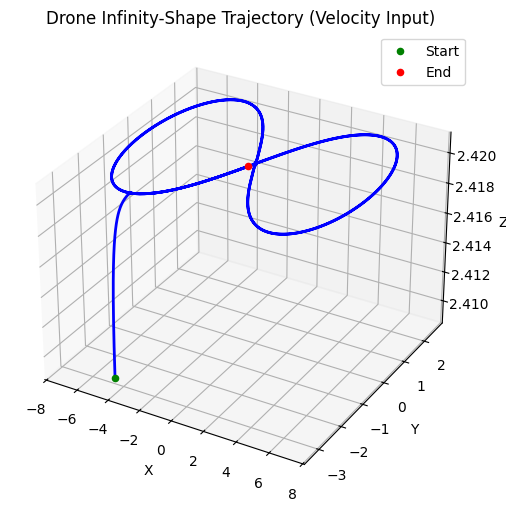

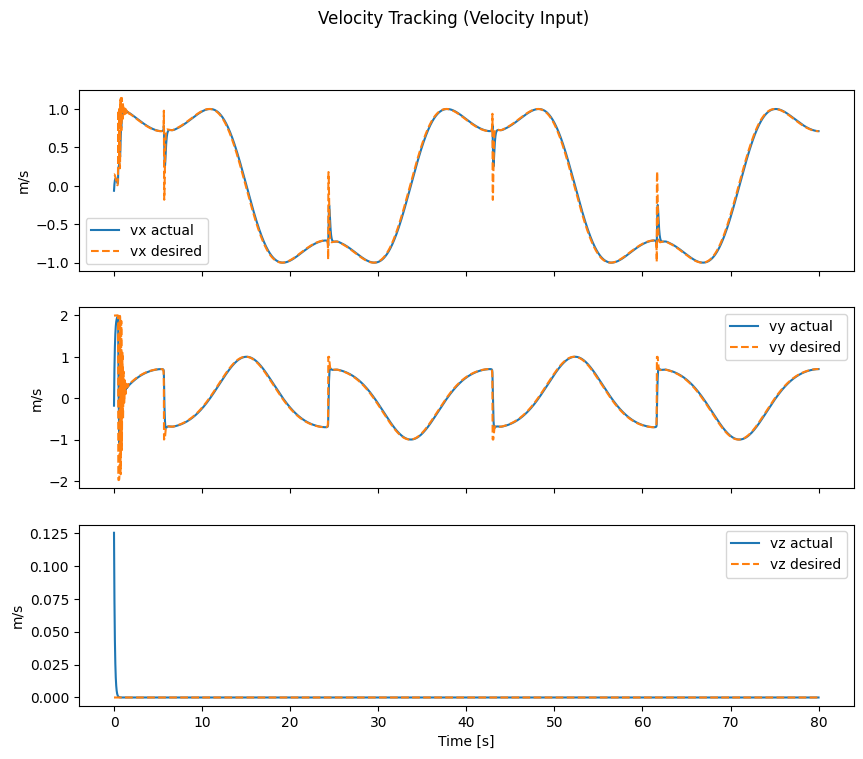

In [2]:
# ====================================
# Main (all parameters set here)
# ====================================

if __name__ == "__main__":
    # --- Global simulation settings
    dt = 0.01
    steps = 8000
    # rng = np.random.default_rng(seed=42)  # reproducibility
    rng = np.random.default_rng()

    # --- Simulator parameters
    sim_params = dict(
        mass=1.0,
        J=np.diag([0.02, 0.02, 0.04]),
        dt=dt,
        init_pos_range=[[-5, -5, 1], [5, 5, 3]],    # random [min,max] for each axis
        init_vel_range=[[-1, -1, -0.5], [1, 1, 0.5]],
        init_omega_range=[[-0.2, -0.2, -0.2], [0.2, 0.2, 0.2]],
        tau_v=0.1,
        pos_bounds=[20.0, 20.0, 10.0],
        vel_bounds=[5.0, 5.0, 5.0],
        omega_bounds=[2.0, 2.0, 2.0],
        rng=rng
    )

    # --- Pattern parameters
    pattern_params = dict(
        a=5.0,
        k_p=1e-3,
        k_t=1.0,
        v_max=2.0,
    )

    # --- Run
    traj, v_log, v_des_log = run_simulation(steps, dt, sim_params, pattern_params)

    # --- Plot
    plot_trajectory(traj)
    plot_velocity(v_log, v_des_log, dt)
